# Cañadata — entrena los cuatro modelos clásicos

Este notebook entrena los cuatro modelos de ML que usaremos en el taller y los guarda en `session1/models/`. **Tiempo total esperado: <3 min.**

Lo ejecutas **antes de S1**. El dashboard de Streamlit que construyes en S1 cargará estos artifacts.

Lo que se guarda:

- `classifier.pkl` — predice `converted` (binario) con RandomForestClassifier
- `regressor.pkl` — predice `quoted_acv_eur` (continuo) con RandomForestRegressor
- `clusterer.pkl` — KMeans (k=3) intentando recuperar los arquetipos ocultos
- `timeseries.pkl` — Prophet sobre conversiones mensuales

Si te entra el gusanillo, al final hay retos opcionales marcados con 🚀.

In [10]:
import time
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    accuracy_score, adjusted_rand_score, mean_absolute_error,
    r2_score, roc_auc_score, silhouette_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

ROOT = Path.cwd()
if ROOT.name == "pre_class":
    ROOT = ROOT.parent
MODELS_DIR = ROOT / "session1" / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(ROOT / "data" / "canadata_leads.csv")
print(f"Cargados {len(df)} leads")
t_start = time.time()

Cargados 728 leads


## Limpieza

El dataset Cañadata es sintético, pero hemos plantado el desorden de un CRM real: NaNs, mayúsculas/minúsculas inconsistentes, alias de país (`Spain`, `España`, `ESP`), tipos mezclados (`demo_requested = "yes"` mezclado con `True`), outliers (`company_size = 99999`, `response_time_hours = 5000`), filas duplicadas, leads de prueba (`'TEST LEAD - DELETE'`), descripciones en inglés que se colaron, fechas en formatos raros y rangos imposibles.

Sin limpiar, el `pd.get_dummies` explota a 15+ valores en `industry` y los modelos aprenden ruido. Esta función hace el wrangling estándar. Léela línea a línea — es la parte aburrida que hace que todo lo demás funcione.


In [11]:
def clean_canadata(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # 1. Quita filas duplicadas (idénticas) y leads de prueba
    df = df.drop_duplicates()
    junk_patterns = ["TEST", "asdf", "DO NOT CONTACT", "XXX", "^a$", "^test$"]
    junk_mask = df["company_name"].fillna("").str.strip().str.contains(
        "|".join(junk_patterns), case=False, regex=True
    )
    df = df[~junk_mask].copy()

    # 2. Strings: trim y normaliza mayúsculas
    for col in ["industry", "country", "source"]:
        df[col] = df[col].astype("string").str.strip()

    # industry: tira a minúsculas, mapea conocidos a la forma canónica, resto → "unknown"
    canonical_industry = {"saas": "SaaS", "fintech": "fintech", "retail": "retail",
                          "logistics": "logistics", "healthcare": "healthcare"}
    df["industry"] = df["industry"].str.lower().map(canonical_industry).fillna("unknown")

    # source: tira a minúsculas, fija typos, resto → "unknown"
    canonical_source = {"organic": "organic", "paid": "paid", "referral": "referral",
                        "conference": "conference", "outbound": "outbound",
                        "conf": "conference", "paid_legacy": "paid", "outbound_v2": "outbound"}
    df["source"] = (
        df["source"].str.lower().str.replace(".", "", regex=False).str.strip()
        .map(canonical_source).fillna("unknown")
    )

    # country: tira a minúsculas, mapea aliases, resto → "unknown"
    country_map = {
        "es": "ES", "spain": "ES", "españa": "ES", "esp": "ES",
        "fr": "FR", "france": "FR", "fra": "FR",
        "de": "DE", "germany": "DE", "deutschland": "DE", "ger": "DE",
        "uk": "UK", "gb": "UK", "united kingdom": "UK", "great britain": "UK",
        "it": "IT", "italy": "IT", "italia": "IT",
        "pt": "PT", "portugal": "PT", "prt": "PT",
    }
    df["country"] = df["country"].str.lower().map(country_map).fillna("unknown")

    # 3. Booleanos a True/False reales
    truthy = {"true", "yes", "y", "1", "sí", "si"}
    def to_bool(v):
        if isinstance(v, bool): return v
        if pd.isna(v): return False
        return str(v).strip().lower() in truthy
    df["demo_requested"] = df["demo_requested"].apply(to_bool)
    df["decision_maker_contacted"] = df["decision_maker_contacted"].apply(to_bool)

    # 4. Numéricos: coerce y filtra outliers imposibles
    for col in ["company_size", "emails_opened", "response_time_hours", "quoted_acv_eur"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    df = df[(df["company_size"] > 0) & (df["company_size"] < 100_000)]
    df = df[(df["response_time_hours"].isna()) | ((df["response_time_hours"] >= 0) & (df["response_time_hours"] <= 720))]
    df = df[(df["quoted_acv_eur"].isna()) | ((df["quoted_acv_eur"] >= 100) & (df["quoted_acv_eur"] <= 500_000))]

    # 5. Fechas: parsea con format="mixed" y descarta futuras
    df["signup_date"] = pd.to_datetime(df["signup_date"].astype(str), errors="coerce", format="mixed")
    df = df[df["signup_date"].notna() & (df["signup_date"] <= pd.Timestamp("2026-06-30"))]

    # 6. Fill mínimos para no perder filas en NaN no críticas
    df["emails_opened"] = df["emails_opened"].fillna(df["emails_opened"].median())
    df["response_time_hours"] = df["response_time_hours"].fillna(df["response_time_hours"].median())
    df["quoted_acv_eur"] = df["quoted_acv_eur"].fillna(df["quoted_acv_eur"].median())
    df["company_description"] = df["company_description"].fillna("")

    return df.reset_index(drop=True)

before = len(df)
df = clean_canadata(df)
print(f"Limpieza: {before} → {len(df)} filas (filtradas {before - len(df)})")
print(f"industry únicos: {sorted(df['industry'].unique())}")
print(f"country únicos:  {sorted(df['country'].unique())}")
print(f"source únicos:   {sorted(df['source'].unique())}")

# Guardamos la versión limpia para que S1 la pueda cargar directamente
clean_path = ROOT / "data" / "canadata_leads_clean.csv"
df.to_csv(clean_path, index=False)
print(f"\nGuardado dataset limpio: {clean_path.relative_to(ROOT)}")


Limpieza: 728 → 697 filas (filtradas 31)
industry únicos: ['SaaS', 'fintech', 'healthcare', 'logistics', 'retail', 'unknown']
country únicos:  ['DE', 'ES', 'FR', 'IT', 'PT', 'UK', 'unknown']
source únicos:   ['conference', 'organic', 'outbound', 'paid', 'referral']

Guardado dataset limpio: data\canadata_leads_clean.csv


## Preparación de features

Tres reglas:

1. `lead_segment_truth` es la verdad oculta. **NUNCA** se usa como feature.
2. `company_description` es texto libre — lo dejamos fuera (lo aprovechará el LLM en S2).
3. `converted_within_days` ocurre DESPUÉS de la conversión, no se usa en clasificación.

Construimos tres matrices distintas: una para clasificación, una para regresión, una para clustering.


In [12]:
META = ["lead_id", "company_name", "company_description", "signup_date",
        "lead_segment_truth", "converted_within_days"]
TARGET_CLF = "converted"
TARGET_REG = "quoted_acv_eur"

def build_features(df, drop):
    cols = [c for c in df.columns if c not in META + drop]
    X = pd.get_dummies(df[cols], columns=["industry", "country", "source"], drop_first=False)
    for c in ["demo_requested", "decision_maker_contacted", "converted"]:
        if c in X.columns:
            X[c] = X[c].astype(int)
    return X

# Clasificación: predice converted, conoce el quoted_acv_eur (cotización ya enviada)
X_clf = build_features(df, drop=[TARGET_CLF])
y_clf = df[TARGET_CLF].astype(int)

# Regresión: predice quoted_acv_eur, sin saber converted (downstream del quote)
X_reg = build_features(df, drop=[TARGET_CLF, TARGET_REG])
y_reg = df[TARGET_REG].values

# Clustering: ningún target
X_clu = build_features(df, drop=[TARGET_CLF, TARGET_REG])

print(f"X_clf: {X_clf.shape}, X_reg: {X_reg.shape}, X_clu: {X_clu.shape}")


X_clf: (697, 25), X_reg: (697, 24), X_clu: (697, 24)


## 1. Clasificación — predice si un lead convierte

Usamos RandomForestClassifier. Es robusto, interpretable mediante `feature_importances_`, y no necesita escalado previo.

In [13]:
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

clf = RandomForestClassifier(
    n_estimators=300, max_depth=10, random_state=42, n_jobs=-1,
)
clf_kind = "random_forest"

t0 = time.time()
clf.fit(Xc_train, yc_train)
t_clf = time.time() - t0

y_pred = clf.predict(Xc_test)
y_proba = clf.predict_proba(Xc_test)[:, 1]
print(f"  modelo:   {clf_kind}")
print(f"  accuracy: {accuracy_score(yc_test, y_pred):.3f}")
print(f"  ROC AUC:  {roc_auc_score(yc_test, y_proba):.3f}")
print(f"  trained in {t_clf:.2f}s")

joblib.dump(
    {"model": clf, "feature_names": list(X_clf.columns), "kind": clf_kind},
    MODELS_DIR / "classifier.pkl",
)
print(f"  guardado en {MODELS_DIR / 'classifier.pkl'}")

  modelo:   random_forest
  accuracy: 0.764
  ROC AUC:  0.840
  trained in 0.42s
  guardado en c:\Users\ferna\Desktop\MDA13_ML\session1\models\classifier.pkl


## 2. Regresión — predice el ACV cotizado

RandomForest sobre el target en escala logarítmica (el ACV es log-normal).


In [14]:
Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg, np.log(y_reg), test_size=0.2, random_state=42
)

reg = RandomForestRegressor(
    n_estimators=200, max_depth=10, random_state=42, n_jobs=-1,
)
t0 = time.time()
reg.fit(Xr_train, yr_train)
t_reg = time.time() - t0

yr_pred_log = reg.predict(Xr_test)
yr_pred = np.exp(yr_pred_log)
yr_true = np.exp(yr_test)
print(f"  R² (log space):  {r2_score(yr_test, yr_pred_log):.3f}")
print(f"  MAE (EUR):       {mean_absolute_error(yr_true, yr_pred):.0f}")
print(f"  trained in {t_reg:.2f}s")

joblib.dump({"model": reg, "feature_names": list(X_reg.columns), "log_target": True}, MODELS_DIR / "regressor.pkl")
print(f"  guardado en {MODELS_DIR / 'regressor.pkl'}")


  R² (log space):  0.769
  MAE (EUR):       1988
  trained in 0.21s
  guardado en c:\Users\ferna\Desktop\MDA13_ML\session1\models\regressor.pkl


## 3. Clustering — recupera los arquetipos

Estandarizamos y aplicamos KMeans con k=3. Comparamos los clusters resultantes con `lead_segment_truth` (que el modelo NO ha visto).


In [15]:
scaler = StandardScaler()
X_clu_scaled = scaler.fit_transform(X_clu)

clusterer = KMeans(n_clusters=3, random_state=42, n_init=10)
t0 = time.time()
labels = clusterer.fit_predict(X_clu_scaled)
t_clu = time.time() - t0

ari = adjusted_rand_score(df["lead_segment_truth"], labels)
sil = silhouette_score(X_clu_scaled, labels)
print(f"  ARI vs ground truth: {ari:.3f}  (1.0 = perfect, 0 = random)")
print(f"  silhouette score:    {sil:.3f}")
print(f"  trained in {t_clu:.2f}s")

joblib.dump(
    {"model": clusterer, "scaler": scaler, "feature_names": list(X_clu.columns)},
    MODELS_DIR / "clusterer.pkl",
)
print(f"  guardado en {MODELS_DIR / 'clusterer.pkl'}")


  ARI vs ground truth: 0.456  (1.0 = perfect, 0 = random)
  silhouette score:    0.094
  trained in 0.09s
  guardado en c:\Users\ferna\Desktop\MDA13_ML\session1\models\clusterer.pkl


## 4. Series temporales — conversiones mensuales con Prophet

**Prophet** (de Meta) descompone la serie en tendencia + estacionalidad + festivos. Es más amable que ARIMA: API tipo sklearn, intervalos de confianza salen de fábrica, no tienes que pelearte con `(p, d, q, P, D, Q, S)`.

Nuestra serie de Cañadata tiene crecimiento (tendencia) y un pico en Q4 (estacionalidad anual). Prophet lo modela en dos líneas.

**Quality gate**: MAPE (error porcentual medio) sobre los últimos 3 meses que el modelo no vio. Honesto y comparable entre runs.


### Antes de Prophet, mira la estacionalidad con los ojos

Antes de entrenar nada, `statsmodels` te descompone la serie en tres líneas:

- **Tendencia**: la dirección de fondo (¿crece, baja, plana?).
- **Estacionalidad**: el patrón que se repite cada año.
- **Residuo**: lo que no explica ni la tendencia ni la estacionalidad.

Si la línea de estacionalidad tiene una forma clara (sube en Q4, baja en verano), entonces el `yearly_seasonality=True` que pondremos a Prophet tiene sentido. Si la estacionalidad es plana, no merece la pena ese parámetro.


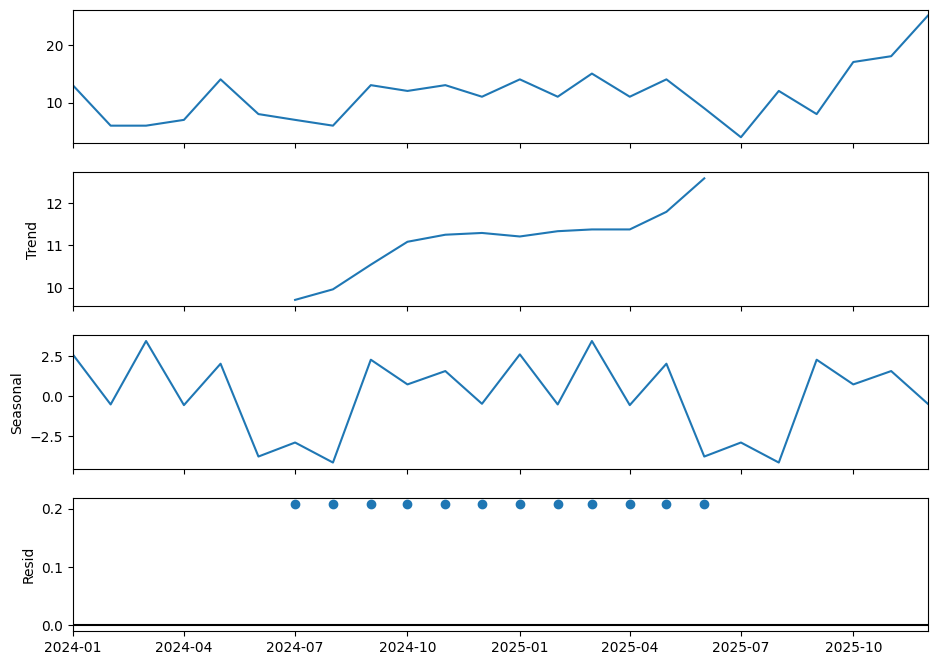

In [16]:
from statsmodels.tsa.seasonal import seasonal_decompose

df["signup_date"] = pd.to_datetime(df["signup_date"])
monthly_conversions = (
    df[df["converted"]].set_index("signup_date").resample("MS").size()
)
monthly_conversions = monthly_conversions.reindex(
    pd.date_range(monthly_conversions.index.min(), monthly_conversions.index.max(), freq="MS"),
    fill_value=0,
)

decomp = seasonal_decompose(monthly_conversions, model="additive", period=12)
fig = decomp.plot()
fig.set_size_inches(10, 7)


In [17]:
import logging
from prophet import Prophet

# Silencia el log ruidoso de cmdstanpy/Prophet ('Chain [1] start processing'
# y similares). Sin esto, ensucian la salida del notebook y de retrain.py.
logging.disable(logging.WARNING)

df["signup_date"] = pd.to_datetime(df["signup_date"])
monthly_conversions = (
    df[df["converted"]].set_index("signup_date").resample("MS").size()
)
monthly_conversions = monthly_conversions.reindex(
    pd.date_range(monthly_conversions.index.min(), monthly_conversions.index.max(), freq="MS"),
    fill_value=0,
)

# Prophet espera columnas 'ds' (datetime) e 'y' (valor)
prophet_df = monthly_conversions.reset_index()
prophet_df.columns = ["ds", "y"]

# Hold out los últimos 3 meses para evaluar (MAPE)
train, test = prophet_df.iloc[:-3], prophet_df.iloc[-3:]

t0 = time.time()
ts_eval = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
ts_eval.fit(train)
test_pred = ts_eval.predict(test[["ds"]])
denom = np.maximum(1, test["y"].values)
mape = float(np.mean(np.abs(test["y"].values - test_pred["yhat"].values) / denom) * 100)

# Re-entrena con TODO el histórico para el modelo final
ts_model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
ts_model.fit(prophet_df)
t_ts = time.time() - t0

# Forecast 6 meses
future = ts_model.make_future_dataframe(periods=6, freq="MS")
forecast = ts_model.predict(future)

print(f"  MAPE en hold-out (3 meses): {mape:.1f}%")
print(f"  trained in {t_ts:.2f}s")
print(f"  forecast 6 meses (yhat): {forecast['yhat'].tail(6).round(1).tolist()}")

joblib.dump(
    {"model": ts_model, "history": monthly_conversions, "validation_mape": mape},
    MODELS_DIR / "timeseries.pkl",
)
print(f"  guardado en {MODELS_DIR / 'timeseries.pkl'}")


  MAPE en hold-out (3 meses): 54.5%
  trained in 8.71s
  forecast 6 meses (yhat): [18.0, 13.6, 15.9, 12.5, 16.2, 15.4]
  guardado en c:\Users\ferna\Desktop\MDA13_ML\session1\models\timeseries.pkl


## Resumen


In [18]:
t_total = time.time() - t_start
print(f"Tiempo total: {t_total:.1f}s\n")
for path in sorted(MODELS_DIR.glob("*.pkl")):
    print(f"  {path.relative_to(ROOT)}  ({path.stat().st_size // 1024} KB)")
print("\n✓ Modelos guardados. Ya estás listo para Sesión 1.")


Tiempo total: 10.4s

  session1\models\classifier.pkl  (4412 KB)
  session1\models\clusterer.pkl  (5 KB)
  session1\models\regressor.pkl  (5310 KB)
  session1\models\timeseries.pkl  (12 KB)

✓ Modelos guardados. Ya estás listo para Sesión 1.


## 🚀 Si te quedas con ganas

1. **Mejora el clasificador**: añade `RandomForestClassifier` con `class_weight="balanced"` y compara ROC-AUC. ¿Cuándo es mejor uno vs otro?
2. **Feature importance**: extrae `clf.feature_importances_` y dibújalo en barras. ¿Las top features cuadran con lo que esperarías de la regla de conversión plantada?
3. **Calibración**: el classifier devuelve probabilidades. Compáralas con la frecuencia real (calibration curve, `from sklearn.calibration import calibration_curve`). ¿Está bien calibrado?
4. **Otro k para clustering**: prueba k=4, k=5. ¿Qué dice el silhouette? ¿Qué dice el ARI? Cuándo conviene desviarse del k "correcto".
5. **Modelo TS alternativo**: ajusta `ExponentialSmoothing` (statsmodels) y compara las predicciones con SARIMAX. ¿Cuál se ve mejor en los últimos 3 meses?
